In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import glob

base = "/content/drive/MyDrive/Clasificare_tumori"

cancer = glob.glob(base + "/cancer/*")
non_cancer = glob.glob(base + "/non_cancer/*")

print("Cancer:", len(cancer))
print("Non-cancer:", len(non_cancer))
print("Exemplu cancer:", cancer[:3])
print("Exemplu non-cancer:", non_cancer[:3])

Cancer: 16
Non-cancer: 10
Exemplu cancer: ['/content/drive/MyDrive/Clasificare_tumori/cancer/BERCHE TU LSS 12.jpg', '/content/drive/MyDrive/Clasificare_tumori/cancer/TU LSD CU SEC SR BILAT4.jpg', '/content/drive/MyDrive/Clasificare_tumori/cancer/tu lsd uiorean1.jpg']
Exemplu non-cancer: ['/content/drive/MyDrive/Clasificare_tumori/non_cancer/sdr condensare lis3.jpg', '/content/drive/MyDrive/Clasificare_tumori/non_cancer/atelectazie LIS tbc tanara9.jpg', '/content/drive/MyDrive/Clasificare_tumori/non_cancer/cond pulm LSD ant 1.jpg']


In [ ]:
import cv2
import skimage
import numpy as np
from PIL import Image

print("cv2:", cv2.__version__)
print("skimage:", skimage.__version__)
print("numpy:", np.__version__)
print("PIL ok")


cv2: 4.13.0
skimage: 0.25.2
numpy: 2.0.2
PIL ok


(np.float64(-0.5), np.float64(1023.5), np.float64(767.5), np.float64(-0.5))

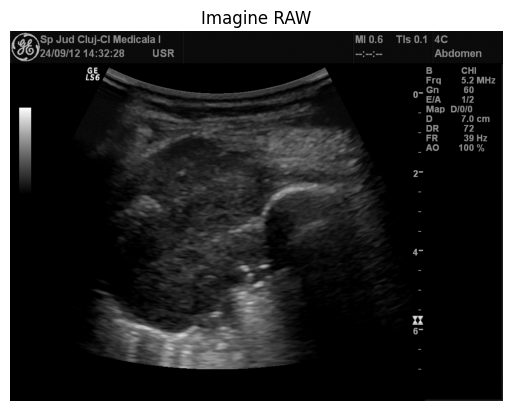

In [ ]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/Clasificare_tumori/cancer/tu cu invazie costala 24_09_2012.bmp"

img = Image.open(img_path)
img = np.array(img)

if len(img.shape) == 3:
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
else:
    gray = img

plt.imshow(gray, cmap="gray")
plt.title("Imagine RAW")
plt.axis("off")


In [ ]:
import cv2
import numpy as np
from PIL import Image
from skimage.filters import threshold_multiotsu
from skimage.segmentation import active_contour
from skimage.filters import gaussian
from skimage import img_as_float

TUMOR_IS_DARK = True

ROI_CLAHE_CLIP = 2.0
ROI_GAUSS = (9, 9)
ROI_MORPH_KERNEL = (10, 10)

TUM_CLAHE_CLIP = 3.0
TUM_MEDIAN_K = 5
MULTI_OTSU_CLASSES = 3

OPEN_K = (7, 7)
CLOSE_K = (11, 11)
OPEN_IT = 1
CLOSE_IT = 2
ROI_ERODE_BORDER = 25
MIN_TUMOR_AREA = 350

RUN_SNAKE = True
SNAKE_ALPHA = 0.01
SNAKE_BETA  = 0.01
SNAKE_GAMMA = 0.001
SNAKE_W_EDGE = 1000.0
SNAKE_W_LINE = -100.0

RUN_WHITE_LINES = True
TOPHAT_K = (31, 31)
WHITE_PERC = 90
WHITE_MIN_AREA = 90


def largest_component(mask255, min_area=200):
    mask = (mask255 > 0).astype(np.uint8)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if n <= 1:
        return np.zeros_like(mask255)
    areas = stats[1:, cv2.CC_STAT_AREA]
    best = 1 + int(np.argmax(areas))
    if stats[best, cv2.CC_STAT_AREA] < min_area:
        return np.zeros_like(mask255)
    return (labels == best).astype(np.uint8) * 255


def fill_holes(mask255):
    m = mask255.copy()
    h, w = m.shape
    flood = m.copy()
    ffmask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(flood, ffmask, (0, 0), 255)
    flood_inv = cv2.bitwise_not(flood)
    return cv2.bitwise_or(m, flood_inv)


def run_snake(gray, init_mask255):
    cnts, _ = cv2.findContours(init_mask255, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea)
    if cv2.contourArea(c) < 300:
        return None
    init = c.squeeze().astype(float)
    if init.ndim != 2 or init.shape[0] < 30:
        return None
    init_rc = np.fliplr(init)
    img = gaussian(img_as_float(gray), sigma=1.0, preserve_range=False)
    snake = active_contour(
        img, init_rc,
        alpha=SNAKE_ALPHA, beta=SNAKE_BETA, gamma=SNAKE_GAMMA,
        w_edge=SNAKE_W_EDGE, w_line=SNAKE_W_LINE
    )
    return snake


def detect_white_lines(gray, roi_mask, tumor_mask=None):
    g = gray.copy()
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, TOPHAT_K)
    tophat = cv2.morphologyEx(g, cv2.MORPH_TOPHAT, k)
    tophat = cv2.normalize(tophat, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    roi_vals = tophat[roi_mask == 255]
    if roi_vals.size < 200:
        return np.zeros_like(gray, np.uint8), []

    thr = np.percentile(roi_vals, WHITE_PERC)
    binm = (tophat >= thr).astype(np.uint8) * 255
    binm = cv2.bitwise_and(binm, binm, mask=roi_mask)

    binm = cv2.medianBlur(binm, 5)
    binm = cv2.morphologyEx(
        binm, cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)),
        iterations=1
    )
    binm = cv2.morphologyEx(
        binm, cv2.MORPH_OPEN,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)),
        iterations=1
    )

    n, labels, stats, _ = cv2.connectedComponentsWithStats((binm > 0).astype(np.uint8), 8)
    out = np.zeros_like(binm)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= WHITE_MIN_AREA:
            out[labels == i] = 255

    out = cv2.dilate(out, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)), iterations=1)

    cnts, _ = cv2.findContours(out, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    smooth_cnts = []
    for c in cnts:
        if len(c) < 20:
            continue
        eps = 0.003 * cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, eps, True)
        smooth_cnts.append(approx)

    return out, smooth_cnts


def segment_full(img_path):
    img_pil = Image.open(img_path)
    road_rgb = np.array(img_pil)

    if len(road_rgb.shape) == 3:
        road_bgr = cv2.cvtColor(road_rgb, cv2.COLOR_RGB2BGR)
        road_gray = cv2.cvtColor(road_bgr, cv2.COLOR_BGR2GRAY)
    else:
        road_gray = road_rgb.copy()
        road_bgr = cv2.cvtColor(road_gray, cv2.COLOR_GRAY2BGR)

    # 1) ROI
    clahe_roi = cv2.createCLAHE(clipLimit=ROI_CLAHE_CLIP, tileGridSize=(8, 8))
    img_contrast = clahe_roi.apply(road_gray)
    img_blur_roi = cv2.GaussianBlur(img_contrast, ROI_GAUSS, 0)

    _, th_roi = cv2.threshold(img_blur_roi, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    th_roi = cv2.morphologyEx(th_roi, cv2.MORPH_CLOSE, np.ones(ROI_MORPH_KERNEL, np.uint8))

    cnts_roi, _ = cv2.findContours(th_roi, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not cnts_roi:
        return road_gray, None, None, None, None

    roi_contour = max(cnts_roi, key=cv2.contourArea)
    roi_mask = np.zeros_like(road_gray, dtype=np.uint8)
    cv2.drawContours(roi_mask, [roi_contour], -1, 255, -1)

    # 2) tumor mask
    den = cv2.medianBlur(road_gray, TUM_MEDIAN_K)
    clahe_t = cv2.createCLAHE(clipLimit=TUM_CLAHE_CLIP, tileGridSize=(8, 8))
    con = clahe_t.apply(den)
    con = cv2.bitwise_and(con, con, mask=roi_mask)

    roi_vals = con[roi_mask == 255]
    if roi_vals.size < 500:
        tumor_mask = np.zeros_like(road_gray, dtype=np.uint8)
    else:
        thr = threshold_multiotsu(roi_vals, classes=MULTI_OTSU_CLASSES)
        regions = np.digitize(con, bins=thr)

        tumor_class = 0 if TUMOR_IS_DARK else (MULTI_OTSU_CLASSES - 1)
        tumor_cand = (regions == tumor_class).astype(np.uint8) * 255
        tumor_cand = cv2.bitwise_and(tumor_cand, tumor_cand, mask=roi_mask)

        roi_eroded = cv2.erode(
            roi_mask,
            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ROI_ERODE_BORDER, ROI_ERODE_BORDER)),
            iterations=1
        )
        tumor_cand = cv2.bitwise_and(tumor_cand, tumor_cand, mask=roi_eroded)

        k_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, OPEN_K)
        k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, CLOSE_K)

        tumor_cand = cv2.morphologyEx(tumor_cand, cv2.MORPH_OPEN, k_open, iterations=OPEN_IT)
        tumor_cand = cv2.morphologyEx(tumor_cand, cv2.MORPH_CLOSE, k_close, iterations=CLOSE_IT)
        tumor_cand = fill_holes(tumor_cand)
        tumor_mask = largest_component(tumor_cand, min_area=MIN_TUMOR_AREA)

    # 3) snake
    snake = None
    if RUN_SNAKE and tumor_mask is not None and np.count_nonzero(tumor_mask) > 0:
        try:
            snake = run_snake(road_gray, tumor_mask)
        except:
            snake = None

    # 4) white lines
    lines_mask, lines_cnts = (None, None)
    if RUN_WHITE_LINES and roi_mask is not None:
        lines_mask, lines_cnts = detect_white_lines(road_gray, roi_mask, tumor_mask=tumor_mask)

    return road_gray, roi_mask, tumor_mask, lines_mask, lines_cnts


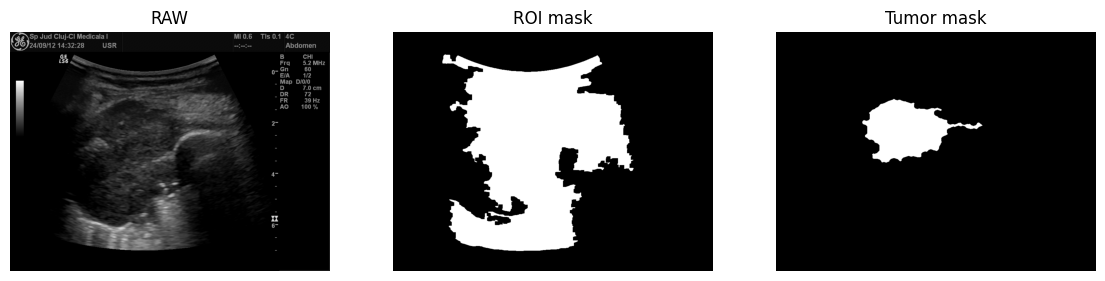

ROI pixels: 220358
Tumor pixels: 38708
White-lines cnts: 35


In [ ]:
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/Clasificare_tumori/cancer/tu cu invazie costala 24_09_2012.bmp"

gray, roi_mask, tumor_mask, lines_mask, lines_cnts = segment_full(img_path)

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.imshow(gray, cmap="gray")
plt.title("RAW")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(roi_mask if roi_mask is not None else gray*0, cmap="gray")
plt.title("ROI mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(tumor_mask if tumor_mask is not None else gray*0, cmap="gray")
plt.title("Tumor mask")
plt.axis("off")

plt.show()

print("ROI pixels:", 0 if roi_mask is None else int((roi_mask>0).sum()))
print("Tumor pixels:", 0 if tumor_mask is None else int((tumor_mask>0).sum()))
print("White-lines cnts:", 0 if lines_cnts is None else len(lines_cnts))


In [ ]:
import glob
import pandas as pd
import numpy as np
import cv2

base = "/content/drive/MyDrive/Clasificare_tumori"

cancer_paths = glob.glob(base + "/cancer/*")
non_paths    = glob.glob(base + "/non_cancer/*")

def extract_features_from_masks(gray, roi_mask, tumor_mask, lines_cnts):
    H, W = gray.shape[:2]
    img_area = H * W + 1e-6

    roi_area   = 0 if roi_mask is None else int((roi_mask > 0).sum())
    tumor_area = 0 if tumor_mask is None else int((tumor_mask > 0).sum())

    # 1) cât din imagine este ROI
    roi_ratio = roi_area / img_area

    # 2) cât din ROI este "tumoare"/zona verde
    tumor_ratio_in_roi = tumor_area / (roi_area + 1e-6)

    # 3-4) formă tumoare: elongation + circularity
    elong = 0.0
    circ = 0.0
    if tumor_area > 0:
        ys, xs = np.where(tumor_mask > 0)
        x0, x1 = xs.min(), xs.max()
        y0, y1 = ys.min(), ys.max()
        bw = (x1 - x0 + 1)
        bh = (y1 - y0 + 1)
        elong = max(bw, bh) / (min(bw, bh) + 1e-6)

        cnts, _ = cv2.findContours(tumor_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if cnts:
            c = max(cnts, key=cv2.contourArea)
            A = cv2.contourArea(c)
            P = cv2.arcLength(c, True)
            circ = (4*np.pi*A) / (P*P + 1e-6)

    # 5-6) intensitate medie în ROI vs în tumoare
    mean_roi = 0.0
    mean_tum = 0.0
    if roi_area > 0:
        mean_roi = float(gray[roi_mask > 0].mean())
    if tumor_area > 0:
        mean_tum = float(gray[tumor_mask > 0].mean())

    # 7-8) linii albe deasupra/dedesubt-aprox
    white_below = 0.0
    white_above = 0.0
    n_white_cnts = 0 if lines_cnts is None else len(lines_cnts)

    if roi_area > 0 and n_white_cnts > 0 and tumor_area > 0:
        lines_mask = np.zeros_like(gray, dtype=np.uint8)
        cv2.drawContours(lines_mask, lines_cnts, -1, 255, 2)

        ys, _ = np.where(tumor_mask > 0)
        y_mid = int(np.median(ys))

        Y = np.arange(H)[:, None]
        below = (lines_mask > 0) & (roi_mask > 0) & (Y >= y_mid)
        above = (lines_mask > 0) & (roi_mask > 0) & (Y <  y_mid)

        white_below = float(below.sum()) / (roi_area + 1e-6)
        white_above = float(above.sum()) / (roi_area + 1e-6)

    return {
        "roi_ratio": roi_ratio,
        "tumor_ratio_in_roi": tumor_ratio_in_roi,
        "elongation": elong,
        "circularity": circ,
        "mean_roi": mean_roi,
        "mean_tumor": mean_tum,
        "white_below": white_below,
        "white_above": white_above,
        "n_white_cnts": n_white_cnts,
    }

rows = []

def process_paths(paths, label):
    for p in paths:
        gray, roi_mask, tumor_mask, lines_mask, lines_cnts = segment_full(p)

        feats = extract_features_from_masks(gray, roi_mask, tumor_mask, lines_cnts)
        feats["path"] = p
        feats["label"] = label
        rows.append(feats)

process_paths(cancer_paths, 1)
process_paths(non_paths, 0)

df = pd.DataFrame(rows)

print("Total imagini:", len(df))
print("Feature-uri folosite:", list(df.columns))

# Afișăm clar TOATE cele 9 feature-uri + label
cols_to_show = [
    "label",
    "roi_ratio","tumor_ratio_in_roi",
    "elongation","circularity",
    "mean_roi","mean_tumor",
    "white_below","white_above",
    "n_white_cnts"
]
print(df[cols_to_show].head())


Total imagini: 26
Feature-uri folosite: ['roi_ratio', 'tumor_ratio_in_roi', 'elongation', 'circularity', 'mean_roi', 'mean_tumor', 'white_below', 'white_above', 'n_white_cnts', 'path', 'label']
   label  roi_ratio  tumor_ratio_in_roi  elongation  circularity   mean_roi  \
0      1   0.351323            0.319626    1.235450     0.296912  59.803802   
1      1   0.466702            0.320084    1.094688     0.073877  72.919964   
2      1   0.365664            0.348051    1.608563     0.286495  57.161470   
3      1   0.350515            0.108081    1.446640     0.140174  62.057808   
4      1   0.458573            0.115183    1.115672     0.179288  68.695073   

   mean_tumor  white_below  white_above  n_white_cnts  
0   39.571045     0.025965     0.036773            41  
1   48.429661     0.042390     0.028769            54  
2   40.202630     0.029057     0.034020            58  
3   35.066918     0.000000     0.055694            31  
4   37.438753     0.016213     0.057104            

/tmp/ipython-input-808888593.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = row[feature_cols].fillna(0.0).values.reshape(1, -1)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


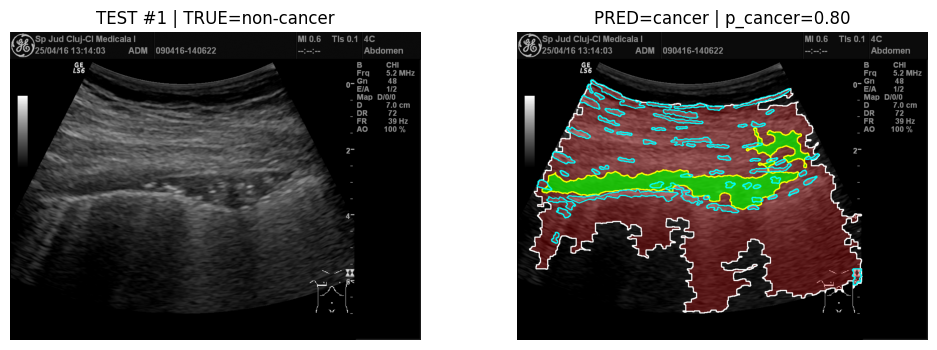

/tmp/ipython-input-808888593.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = row[feature_cols].fillna(0.0).values.reshape(1, -1)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


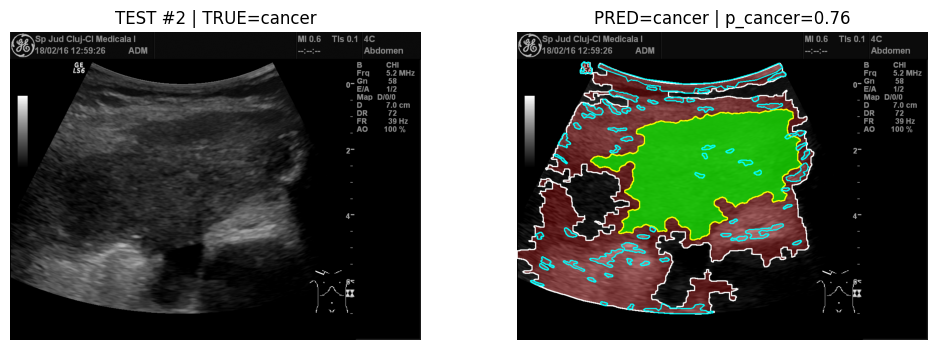

/tmp/ipython-input-808888593.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = row[feature_cols].fillna(0.0).values.reshape(1, -1)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


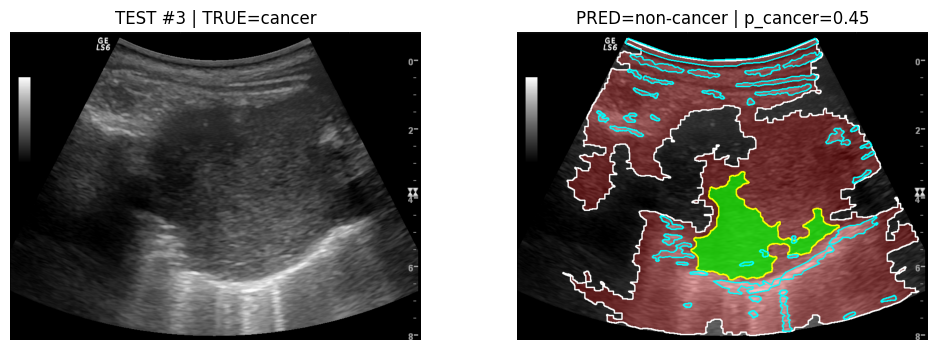

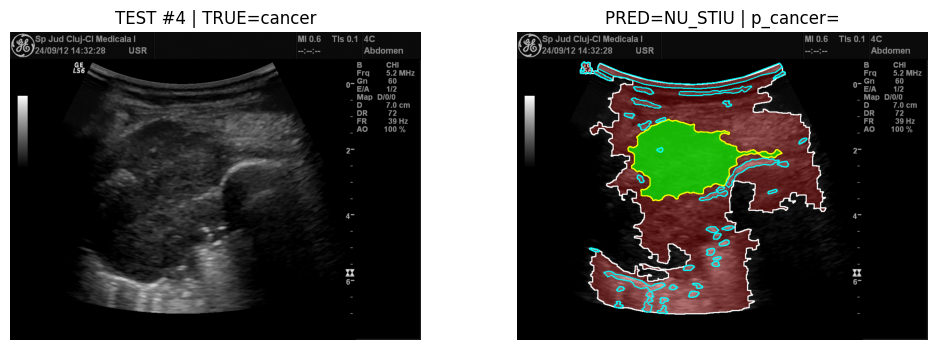

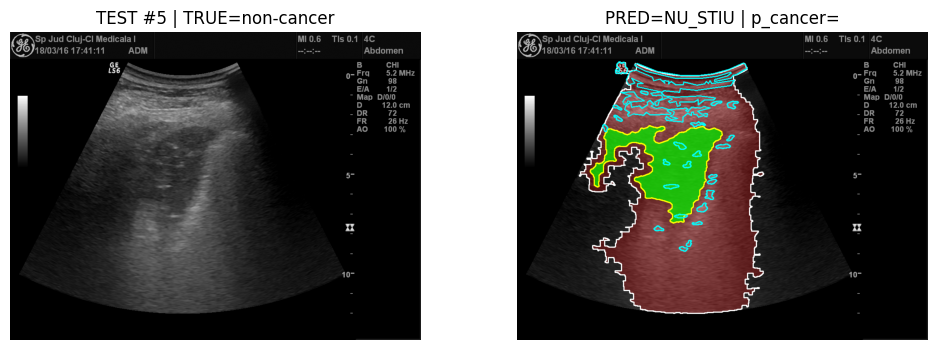

/tmp/ipython-input-808888593.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = row[feature_cols].fillna(0.0).values.reshape(1, -1)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


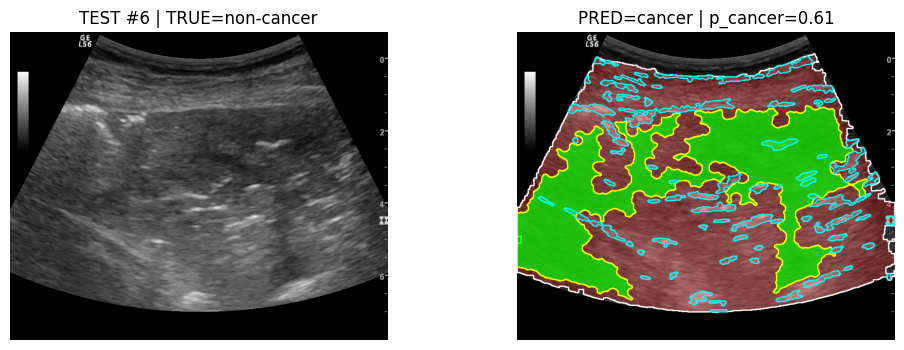

/tmp/ipython-input-808888593.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = row[feature_cols].fillna(0.0).values.reshape(1, -1)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


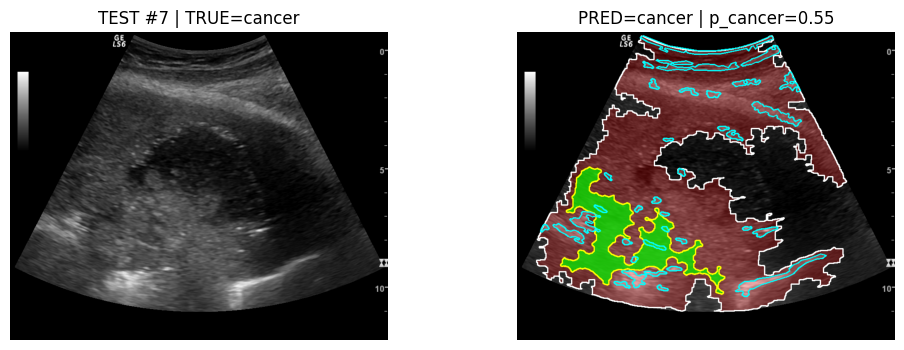

/tmp/ipython-input-808888593.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = row[feature_cols].fillna(0.0).values.reshape(1, -1)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


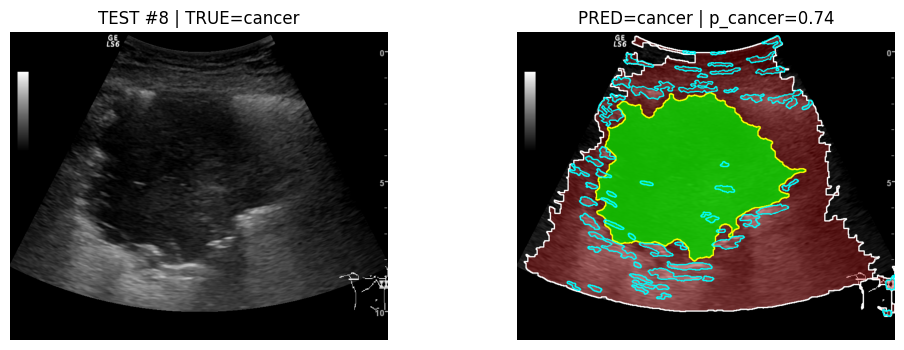

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np
import cv2

# 1) split 70/30
df_train, df_test = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label"]
)

# 2) antrenăm modelul doar pe train
X_train = df_train[feature_cols].fillna(0.0)
y_train = df_train["label"].astype(int)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])
model.fit(X_train, y_train)

# 3) funcție overlay pentru o imagine
def make_overlay(gray, roi_mask, tumor_mask, lines_cnts):
    bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    overlay = bgr.copy()

    # ROI roșu
    if roi_mask is not None:
        red = np.zeros_like(overlay); red[:,:,2] = 255
        blend = cv2.addWeighted(overlay, 0.75, red, 0.25, 0)
        overlay = np.where(roi_mask[...,None] > 0, blend, overlay)

        # contur ROI alb
        cnts, _ = cv2.findContours(roi_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        if cnts:
            c = max(cnts, key=cv2.contourArea)
            cv2.drawContours(overlay, [c], -1, (255,255,255), 2)

    # zona verde + contur galben
    if tumor_mask is not None:
        green = np.zeros_like(overlay); green[:,:,1] = 255
        blend = cv2.addWeighted(overlay, 0.30, green, 0.70, 0)
        overlay = np.where(tumor_mask[...,None] > 0, blend, overlay)

        cnts, _ = cv2.findContours(tumor_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if cnts:
            c = max(cnts, key=cv2.contourArea)
            cv2.drawContours(overlay, [c], -1, (0,255,255), 2)

    # linii albe
    if lines_cnts is not None and len(lines_cnts) > 0:
        cv2.drawContours(overlay, lines_cnts, -1, (255,255,0), 2)

    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

# 4) predicție cu “NU ȘTIU”
LOW, HIGH = 0.49, 0.51
ROI_THR = 0.35

def predict_3class(row):
    if row["roi_ratio"] < ROI_THR:
        return "NU_STIU", None

    x = row[feature_cols].fillna(0.0).values.reshape(1, -1)
    p_cancer = model.predict_proba(x)[0][1]

    if p_cancer < LOW:
        return "non-cancer", p_cancer
    elif p_cancer > HIGH:
        return "cancer", p_cancer
    else:
        return "NU_STIU", p_cancer

# 5) afișăm TOATE imaginile din TEST (raw + overlay)
for i, (_, row) in enumerate(df_test.iterrows(), start=1):
    img_path = row["path"]
    true_label = "cancer" if row["label"] == 1 else "non-cancer"
    pred_label, p = predict_3class(row)

    gray, roi_mask, tumor_mask, lines_mask, lines_cnts = segment_full(img_path)
    overlay_rgb = make_overlay(gray, roi_mask, tumor_mask, lines_cnts)

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.imshow(gray, cmap="gray")
    plt.title(f"TEST #{i} | TRUE={true_label}")
    plt.axis("off")

    plt.subplot(1,2,2)
    ptxt = "" if p is None else f"{p:.2f}"
    plt.imshow(overlay_rgb)
    plt.title(f"PRED={pred_label} | p_cancer={ptxt}")
    plt.axis("off")

    plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# features folosite (fără path/label)
feature_cols = [
    "roi_ratio","tumor_ratio_in_roi","elongation","circularity",
    "mean_roi","mean_tumor","white_below","white_above","n_white_cnts"
]

X = df[feature_cols].fillna(0.0)
y = df["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

pred = model.predict(X_test)
print("Confusion matrix:\n", confusion_matrix(y_test, pred))
print("\nRaport:\n", classification_report(y_test, pred))


Confusion matrix:
 [[0 3]
 [1 4]]

Raport:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.57      0.80      0.67         5

    accuracy                           0.50         8
   macro avg       0.29      0.40      0.33         8
weighted avg       0.36      0.50      0.42         8



In [ ]:
# probabilitatea ca imaginea sa fie cancer
probs = model.predict_proba(X_test)

def predict_with_unknown(prob, low=0.49, high=0.51):
    """
    prob = probabilitatea pentru cancer (clasa 1)
    """
    if prob < low:
        return "non-cancer"
    elif prob > high:
        return "cancer"
    else:
        return "NU_STIU"

results = []
for p in probs:
    results.append(predict_with_unknown(p[1]))

for i, r in enumerate(results):
    print(f"Imagine {i}: {r}")


Imagine 0: cancer
Imagine 1: cancer
Imagine 2: non-cancer
Imagine 3: cancer
Imagine 4: cancer
Imagine 5: cancer
Imagine 6: cancer
Imagine 7: cancer
